In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Read the dataset

In [17]:
df=pd.read_csv('headlines.csv',header=None)

In [18]:
df

,0
0,Budget to set scene for election\n \n Gordon B...
1,Army chiefs in regiments decision\n \n Militar...
2,Howard denies split over ID cards\n \n Michael...
3,Observers to monitor UK election\n \n Minister...
4,Kilroy names election seat target\n \n Ex-chat...
...,...
2220,India opens skies to competition\n \n India wi...
2221,Yukos bankruptcy 'not US matter'\n \n Russian ...
2222,Survey confirms property slowdown\n \n Governm...
2223,High fuel prices hit BA's profits\n \n British...


In [19]:
print(df[0][0])

Budget to set scene for election
 
 Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from Â£60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour.
 
 Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about Â£2bn to spare.
 
 - Increase in the stamp duty threshold from Â£60,000 
  - A freeze on petrol duty 
  - An extension of tax credit scheme for poorer families 
  - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties' general election manifestos. Ten years ago, buyers had a much greater chanc

### Data Preprocessing

In [20]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

In [21]:
swords=stopwords.words('english')
wnl=WordNetLemmatizer()

In [33]:
# adding lemmatization

def lemmatize(word):
    tag = pos_tag([word])
    pos = 'n'
    wnl = WordNetLemmatizer()
    if tag[0][1].startswith('N'):
        pos = 'n'
    elif tag[0][1].startswith('V'):
        pos = 'v'
    elif tag[0][1].startswith('J'):
        pos = 'a'
    elif tag[0][1].startswith('R'):
        pos = 'r'

    return (wnl.lemmatize(word, pos=pos))

In [34]:
def clean_text(sent):
    tokens1=word_tokenize(sent)
    tokens2=[token for token in tokens1 if token.isalpha()]
    tokens3=[token.lower() for token in tokens2 if token.lower() not in swords]
    tokens4=[lemmatize(token) for token in tokens3]
    return tokens4

In [49]:
swords.extend(['said','made','make','new','one','say'])

In [50]:
sent='It was expected raining today. But not completed.'

In [51]:
clean_text(sent)

['expect', 'rain', 'today', 'complete']

In [52]:
cleaned_text=df[0].apply(clean_text)

In [53]:
cleaned_text

0       [budget, set, scene, election, gordon, brown, ...
1       [army, chief, regiment, decision, military, ch...
2       [howard, denies, split, id, card, michael, how...
3       [observer, monitor, uk, election, minister, in...
4       [kilroy, name, election, seat, target, show, h...
                              ...                        
2220    [india, open, sky, competition, india, allow, ...
2221    [yukos, bankruptcy, u, matter, russian, author...
2222    [survey, confirms, property, slowdown, governm...
2223    [high, fuel, price, hit, ba, profit, british, ...
2224    [u, trade, gap, hit, record, gap, u, export, i...
Name: 0, Length: 2225, dtype: object

In [54]:
final_text=' '.join(cleaned_text.sum())

In [55]:
final_text

'budget set scene election gordon brown seek put economy centre labour bid third term power delivers ninth budget gmt expect stress importance continued economic stability low unemployment interest rate chancellor expect freeze petrol duty raise stamp duty threshold conservative lib dems insist voter face high tax labour treasury official giveaway mr brown thought spare increase stamp duty threshold freeze petrol duty extension tax credit scheme poorer family possible help pensioner stamp duty threshold rise intend help first time buyer likely theme three main party general election manifesto ten year ago buyer much great chance avoid stamp duty close half million property england wale alone sell less since average uk property price double start threshold stamp duty increase tax credit result number property incur stamp duty rocket government tax take liberal democrat unveiled proposal raise stamp duty threshold february tory also thought likely propose increase threshold shadow chance

In [56]:
from wordcloud import WordCloud

In [57]:
wcloud=WordCloud(background_color='white').generate(final_text)

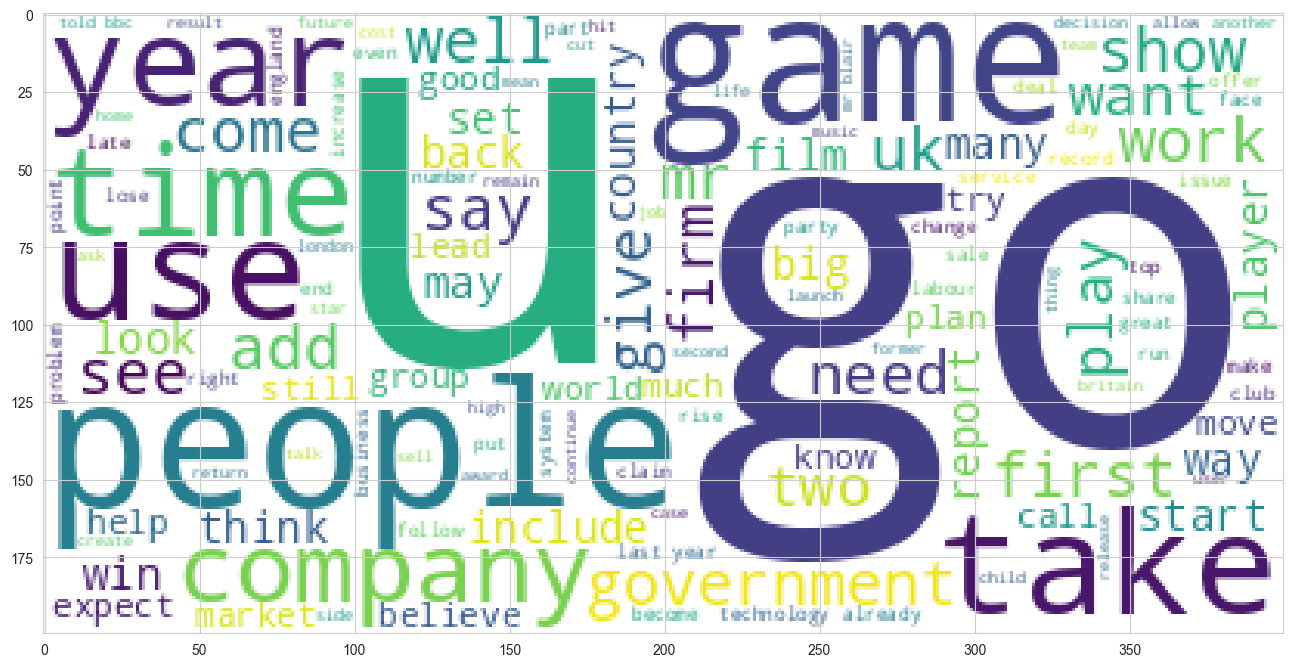

In [58]:
plt.figure(figsize=(16,9))
plt.imshow(wcloud)

### Vectorization

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [62]:
tfidf=TfidfVectorizer(analyzer=clean_text)

In [63]:
x_new=tfidf.fit_transform(df[0])

In [64]:
x_new.shape

(2225, 21406)

In [65]:
# pip install kneed

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Creating clusters

In [67]:
from sklearn.cluster import KMeans

In [68]:
sse=[]
for k in range(1,16):
    km=KMeans(n_clusters=k,random_state=0,n_init='auto')
    km.fit_predict(x_new)
    sse.append(km.inertia_)

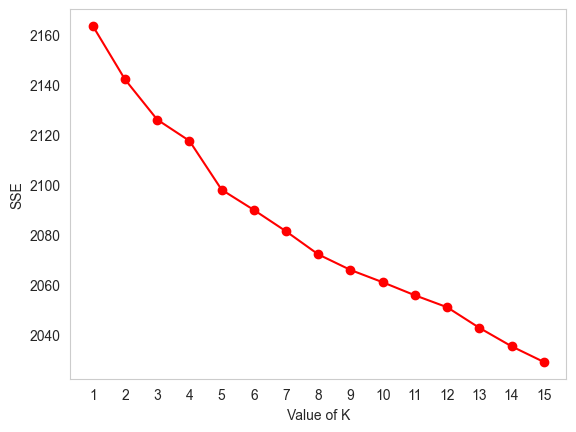

In [69]:
plt.xlabel('Value of K')
plt.ylabel('SSE')
plt.grid()
plt.xticks(range(1,16))
plt.plot(range(1,16),sse,marker='o',color='r')

In [70]:
from kneed import KneeLocator

In [72]:
kl = KneeLocator(range(1,16),sse,curve='convex',direction='decreasing')

In [74]:
kl.elbow

np.int64(5)

In [75]:
km=KMeans(n_clusters=5,random_state=0,n_init='auto')

In [76]:
labels=km.fit_predict(x_new)

In [77]:
labels

array([4, 3, 4, ..., 3, 3, 3], shape=(2225,), dtype=int32)

In [78]:
km.labels_

array([4, 3, 4, ..., 3, 3, 3], shape=(2225,), dtype=int32)

In [83]:
zero=[label for label in x_new if km.labels_[0]==0]

In [86]:
len(labels)

2225

In [87]:
zero=cleaned_text[labels==0]
one=cleaned_text[labels==1]
two=cleaned_text[labels==2]
three=cleaned_text[labels==3]
four=cleaned_text[labels==4]

In [88]:
zero.shape,one.shape,two.shape,three.shape,four.shape

((378,), (352,), (519,), (692,), (284,))

In [89]:
" ".join(zero.values[0])

'mp issue blackberry threat mp thrown common use blackberry chamber speaker michael martin rule handheld computer use phone pager send device gain prominence week alastair campbell use accidentally send message newsnight journalist mr martin reveal mp use blackberry debate also caution member use hidden earpiece use electronic device common chamber long frown sound mobile phone pager result strong rebuke either speaker deputy speaker chair debate common charge ensure order chamber enforce rule convention house always mp chosen colleague nominate give party political allegiance'

In [90]:
zero.values

array([list(['mp', 'issue', 'blackberry', 'threat', 'mp', 'thrown', 'common', 'use', 'blackberry', 'chamber', 'speaker', 'michael', 'martin', 'rule', 'handheld', 'computer', 'use', 'phone', 'pager', 'send', 'device', 'gain', 'prominence', 'week', 'alastair', 'campbell', 'use', 'accidentally', 'send', 'message', 'newsnight', 'journalist', 'mr', 'martin', 'reveal', 'mp', 'use', 'blackberry', 'debate', 'also', 'caution', 'member', 'use', 'hidden', 'earpiece', 'use', 'electronic', 'device', 'common', 'chamber', 'long', 'frown', 'sound', 'mobile', 'phone', 'pager', 'result', 'strong', 'rebuke', 'either', 'speaker', 'deputy', 'speaker', 'chair', 'debate', 'common', 'charge', 'ensure', 'order', 'chamber', 'enforce', 'rule', 'convention', 'house', 'always', 'mp', 'chosen', 'colleague', 'nominate', 'give', 'party', 'political', 'allegiance']),
       list(['game', 'warning', 'clearer', 'violent', 'video', 'game', 'carry', 'large', 'warning', 'parent', 'understand', 'child', 'play', 'trade', 'in

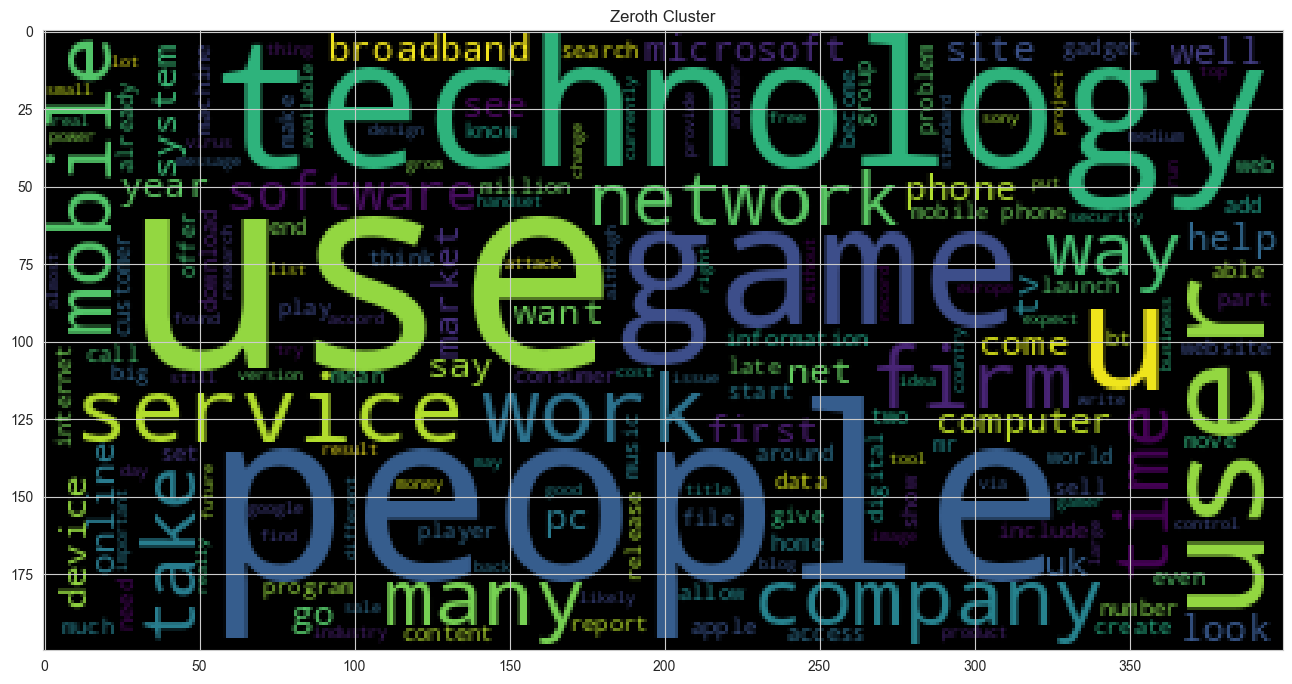

In [94]:
wc0=WordCloud().generate(' '.join(zero.sum()))
plt.figure(figsize=(16,9))
plt.title('Zeroth Cluster')
plt.imshow(wc0)

In [95]:
from nltk import FreqDist

In [96]:
freq=FreqDist(zero.sum())

In [97]:
freq.most_common(10)

[('people', 952),
 ('use', 876),
 ('game', 807),
 ('technology', 602),
 ('mobile', 596),
 ('phone', 552),
 ('service', 525),
 ('also', 516),
 ('mr', 482),
 ('get', 468)]

In [98]:
freq=FreqDist(two.sum())
freq.most_common(10)

[('game', 709),
 ('win', 589),
 ('go', 532),
 ('player', 496),
 ('take', 478),
 ('get', 471),
 ('play', 469),
 ('england', 465),
 ('year', 454),
 ('first', 448)]

In [100]:
freq=FreqDist(four.sum())
freq.most_common(10)

[('mr', 1512),
 ('would', 817),
 ('labour', 732),
 ('party', 675),
 ('election', 626),
 ('blair', 545),
 ('government', 530),
 ('tory', 485),
 ('people', 452),
 ('minister', 420)]

In [101]:
freq=FreqDist(one.sum())
freq.most_common(10)

[('film', 1002),
 ('best', 605),
 ('award', 563),
 ('year', 558),
 ('star', 434),
 ('show', 431),
 ('music', 372),
 ('also', 367),
 ('u', 325),
 ('include', 317)]

In [102]:
freq=FreqDist(three.sum())
freq.most_common(10)

[('year', 1114),
 ('u', 952),
 ('mr', 848),
 ('would', 762),
 ('company', 681),
 ('also', 597),
 ('firm', 579),
 ('government', 574),
 ('market', 534),
 ('last', 462)]

In [103]:
result={
    0:'Technology',
    1:'Entertainment',
    2:'Sports',
    3:'Business',
    4:'Politics',
}

In [104]:
new='''Nvidia has claimed it is "a generation ahead" of rivals in the artificial intelligence (AI) industry amid growing suggestions a rival may emerge to threaten to its market dominance - and multi-trillion dollar valuation.

Shares in the chip giant fell on Tuesday, following a report Meta planned to spend billions on AI chips developed by Google to power its data centres.

In a statement on X, Nvidia, the world's most valuable company, said it was the only platform which "runs every AI model and does it everywhere computing is done".

In response, Google said it was committed to "supporting both" its own and Nvidia's chips.

Nvidia's chips have become a critical part of powering the data centres behind many of the most popular AI tools, such as ChatGPT.

In October it became the first company ever to be valued at $5tn (£3.8tn).

The American firm has been looking to expand its reach further in recent months, announcing an agreement in October to supply some of its most advanced artificial intelligence (AI) chips to South Korea's government, as well as Samsung, LG, and Hyundai.

'Healthy' competition
Google rents access to its chips, called tensor processing units (TPUs), through Google Cloud to AI developers.

In other words, they are not sold externally - but kept for the tech giant's own data centres.

But if recent reports are correct - that the tech company could be in talks to sell its chips to power other data centres - it would represent a significant change.

The news saw Nvidia shares fall nearly 6% on Tuesday, whilst those in Alphabet, Google's parent company, rose by nearly the same percentage.

In the hours following the drop, the chip giant posted on X to state it still offered "greater performance" and "versatility" than the types of chips Google is producing.

In the past year, both Amazon and Microsoft have announced they also have AI chips in development.

Dame Wendy Hall, Regius Professor of Computer Science at the University of Southampton, told the BBC's Today programme the news of the potential deal between Google and Meta was "healthy" for the market.

"Investment is pouring into this area," she said.

"At the moment there is no real return on that investment except for Nvidia".'''

In [108]:
new=tfidf.transform([new])

TypeError: expected string or bytes-like object, got 'csr_matrix'